# 🏙️ Análise de Precificação e Rentabilidade: Mercado Imobiliário de São Paulo
**Objetivo:** Investigar dinâmicas de preço e comportamento do mercado imobiliário paulistano (2020-2026) utilizando dados de vendas e locações.
**Perguntas de Negócio Respondidas:**
1. Qual o impacto real no preço de estar próximo a estações de metrô/trem?
2. Em quais bairros o retorno sobre o aluguel (Yield) é mais vantajoso para o investidor?

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

# 1. Faz o download do dataset direto do Kaggle para o Colab
caminho_pasta = kagglehub.dataset_download("sergionefedov/so-paulo-real-estate-sales-and-rentals-2020-2026")
# 2. Mostra quais arquivos (tabelas) vieram dentro dessa pasta
arquivos = os.listdir(caminho_pasta)
print("Arquivos disponíveis no dataset:")
for arquivo in arquivos:
    print(f"- {arquivo}")

100%|██████████| 5.00M/5.00M [00:00<00:00, 135MB/s]

Extracting files...
Arquivos disponíveis no dataset:
- rentals.csv
- secondary_sales.csv
- transit_stations.csv
- bairro_prices_monthly.csv
- new_construction.csv


In [3]:
# Importando as bases principais usando o caminho da pasta que baixamos
df_vendas = pd.read_csv(f"{caminho_pasta}/secondary_sales.csv")
df_aluguel = pd.read_csv(f"{caminho_pasta}/rentals.csv")

# Mostrando as 5 primeiras linhas da base de vendas (imóveis usados)
display(df_vendas.head())

# Mostrando um resumo técnico da tabela (tipos de dados e valores nulos)
print("\n--- RESUMO TÉCNICO DA BASE DE VENDAS ---")
df_vendas.info()

,id,date_listed,bairro,zona,tier,lat,lon,property_type,dorms,area_util_m2,...,price_brl,price_per_m2_util_brl,price_usd,price_per_m2_util_usd,condominio_brl_monthly,iptu_brl_annual,brl_usd_rate_at_listing,selic_rate_at_listing,mortgage_rate_at_listing,ipca_yoy_at_listing
0,S000001,2024-11-23,Saúde,Zona Sul,premium,-23.61819,-46.64459,2_dorm,2,80.5,...,1285000,15956,210586,2616,1139,8542,6.1,11.25,14.25,4.8
1,S000002,2021-01-16,Campo Belo,Zona Sul,premium,-23.62030,-46.66071,2_dorm,2,87.1,...,839000,9629,161323,1852,979,5579,5.2,2.00,5.00,8.4
2,S000003,2024-03-27,Jardim Paulistano,Zona Oeste,luxury,-23.58192,-46.68370,2_dorm,2,77.6,...,1822000,23475,350341,4514,1454,12115,5.2,10.50,13.50,4.0
3,S000004,2024-02-21,Aclimação,Zona Sul,premium,-23.56802,-46.62658,2_dorm,2,65.3,...,811000,12418,155964,2388,996,5393,5.2,10.50,13.50,4.0
4,S000005,2024-03-15,Vila Prudente,Zona Leste,mid,-23.58854,-46.57980,2_dorm,2,76.4,...,398000,5215,76622,1003,1052,2650,5.2,10.50,13.50,4.0



--- RESUMO TÉCNICO DA BASE DE VENDAS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        50000 non-null  object 
 1   date_listed               50000 non-null  object 
 2   bairro                    50000 non-null  object 
 3   zona                      50000 non-null  object 
 4   tier                      50000 non-null  object 
 5   lat                       50000 non-null  float64
 6   lon                       50000 non-null  float64
 7   property_type             50000 non-null  object 
 8   dorms                     50000 non-null  int64  
 9   area_util_m2              50000 non-null  float64
 10  area_total_m2             50000 non-null  float64
 11  floor                     50000 non-null  int64  
 12  total_floors              50000 non-null  int64  
 13  year_built         

,price_brl,area_util_m2,dorms,vagas_garagem
count,50000.00,50000.00,50000.00,50000.00
mean,775534.52,77.14,2.00,1.43
std,741563.16,39.91,1.08,0.99
min,36000.00,20.00,0.00,0.00
25%,297000.00,51.20,1.00,1.00
50%,538000.00,68.70,2.00,1.00
75%,979000.00,92.40,3.00,2.00
max,8713000.00,363.50,4.00,4.00


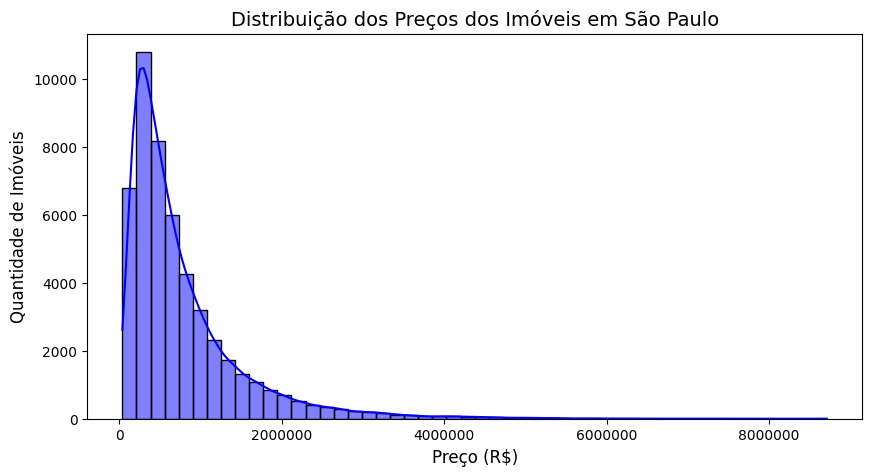

In [4]:
from posix import PRIO_PROCESS
import matplotlib.pyplot as plt
import seaborn as sns

#1. Resumo estatístico rápido (focando em preço e área)
colunas_analise = ['price_brl', 'area_util_m2', 'dorms', 'vagas_garagem']
display(df_vendas[colunas_analise].describe().round(2))

#2. Criando o nosso primeiro gráfico: A distribuição dos preços
plt.figure(figsize=(10,5))
sns.histplot(df_vendas['price_brl'], bins=50, kde=True, color='blue')
plt.title('Distribuição dos Preços dos Imóveis em São Paulo', fontsize=14)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Quantidade de Imóveis', fontsize=12)

# Ajudando o eixo X para não ficar em notação científica (ex: 1e6)
plt.ticklabel_format(style='plain', axis='x')
plt.show()


## 🚆 1. O Efeito da Proximidade ao Metrô
A sabedoria popular dita que "quanto mais perto do metrô, mais caro". Vamos testar essa hipótese categorizando as distâncias em três faixas de caminhada e analisando o preço mediano do metro quadrado.

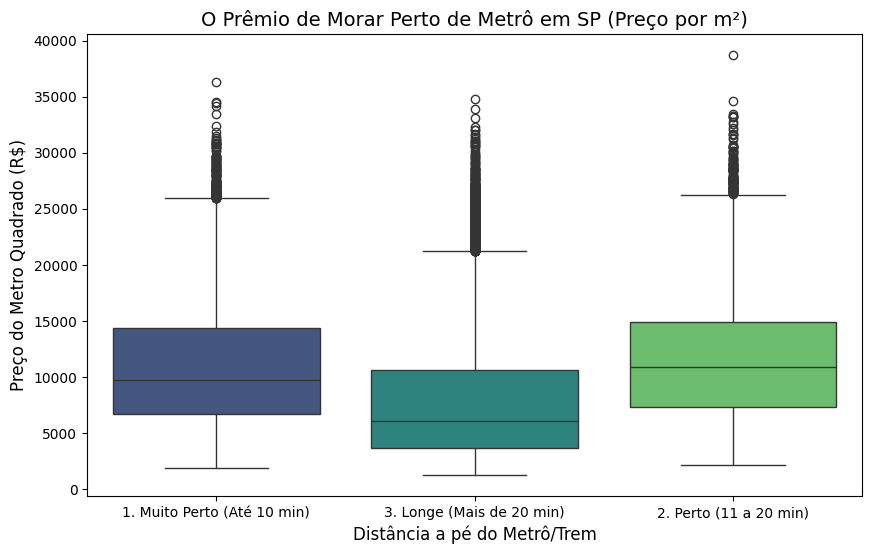


--- MÉDIA DE PREÇO POR M² SEGUNDO A DISTÂNCIA DO METRÔ ---


,price_per_m2_util_brl
proximidade_metro,
1. Muito Perto (Até 10 min),10816.20
2. Perto (11 a 20 min),11697.25
3. Longe (Mais de 20 min),7898.94


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. Função para criar as categorias de distância
def categorizar_distancia(minutos):
    if minutos <= 10:
        return '1. Muito Perto (Até 10 min)'
    elif minutos <= 20:
        return '2. Perto (11 a 20 min)'
    else:
        return '3. Longe (Mais de 20 min)'

#2. Criando uma COLUNA NOVA no nosso banco de dados
df_vendas['proximidade_metro'] = df_vendas['transit_distance_min'].apply(categorizar_distancia)

#3. Criando o gráfico visual (Boxplot)
plt.figure(figsize=(10,6))
#Usamos o preço por metro quadrado para ser uma comparação justa entre aptos grandes e pequenos
sns.boxplot(data=df_vendas, x='proximidade_metro', y='price_per_m2_util_brl', hue='proximidade_metro', palette='viridis', legend=False)
plt.title('O Prêmio de Morar Perto de Metrô em SP (Preço por m²)', fontsize= 14)
plt.xlabel('Distância a pé do Metrô/Trem', fontsize=12)
plt.ylabel('Preço do Metro Quadrado (R$)', fontsize=12)
plt.show()

#4. Mostrando o resumo em números absolutos
print('\n--- MÉDIA DE PREÇO POR M² SEGUNDO A DISTÂNCIA DO METRÔ ---')
display(df_vendas.groupby('proximidade_metro')['price_per_m2_util_brl'].mean().round(2))


**💡 Insight de Negócio:** Os dados quebram a hipótese inicial. Imóveis entre 11 e 20 minutos de caminhada (R$ 11.697/m²) são mais valorizados do que aqueles a menos de 10 minutos (R$ 10.816/m²). Isso indica a "Zona Ideal": perto o suficiente para ir a pé, mas longe o suficiente para evitar a poluição sonora, falta de privacidade e tráfego intenso do primeiro quarteirão das estações.

In [12]:
# Listando o nome de todas as colunas da tabela de aluguel
print(df_aluguel.columns.tolist())

['id', 'date_listed', 'bairro', 'zona', 'tier', 'lat', 'lon', 'property_type', 'dorms', 'area_util_m2', 'floor', 'total_floors', 'vagas_garagem', 'seguranca_24h', 'lazer_completo', 'mobiliado', 'condition', 'transit_station', 'transit_line', 'transit_distance_min', 'to_faria_lima_km', 'monthly_rent_brl', 'condominio_brl_monthly', 'iptu_brl_annual', 'total_monthly_cost_brl', 'rent_per_m2_util_brl', 'garantia_locaticia', 'monthly_rent_usd', 'brl_usd_rate_at_listing', 'ipca_yoy_at_listing']


## 💰 2. Comprar vs. Alugar: Análise de Yield Anual
Para investidores, a métrica mais importante é o Yield (Retorno percentual do aluguel sobre o valor de compra). Vamos cruzar a base de vendas com a base de locação para descobrir onde o aluguel rende mais.

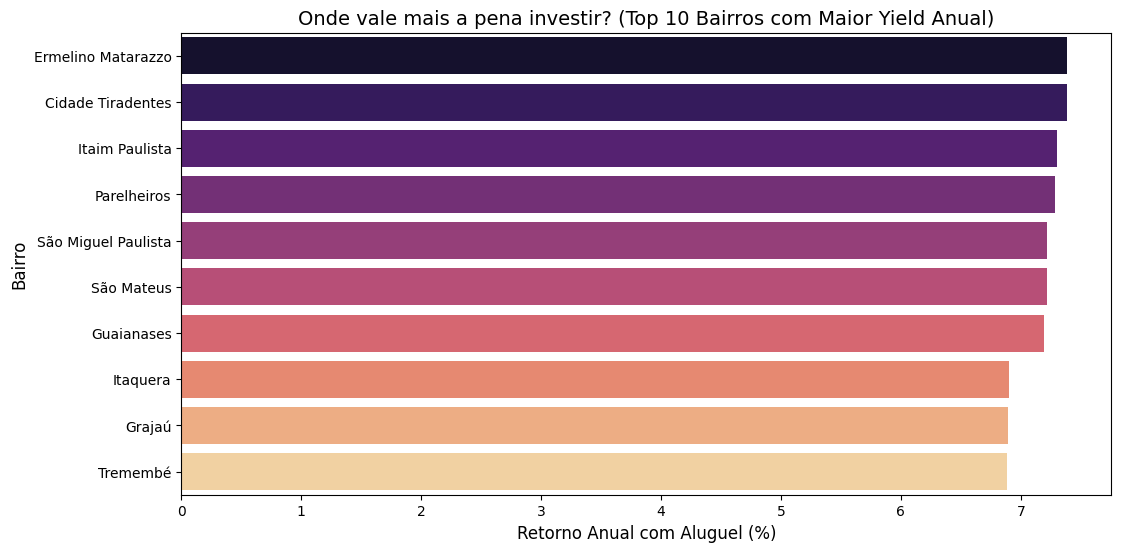


--- TABELA DOS BAIRROS MAIS RENTÁVEIS PARA INVESTIDORES ---


,bairro,preco_compra_m2,preco_aluguel_m2,yield_anual_pct
23,Ermelino Matarazzo,3185.0,19.60,7.38
20,Cidade Tiradentes,2389.0,14.70,7.38
32,Itaim Paulista,2579.5,15.70,7.30
51,Parelheiros,2405.0,14.60,7.28
67,São Miguel Paulista,2793.0,16.80,7.22
66,São Mateus,2893.0,17.40,7.22
28,Guaianases,2486.0,14.90,7.19
33,Itaquera,3789.0,21.80,6.90
26,Grajaú,3273.0,18.80,6.89
70,Tremembé,3424.0,19.65,6.89


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Agrupar vendas por bairro (mediana do preço por m²)
vendas_bairro = df_vendas.groupby('bairro')['price_per_m2_util_brl'].median().reset_index()
vendas_bairro.rename(columns={'price_per_m2_util_brl': 'preco_compra_m2'}, inplace=True)

# 2. Agrupar aluguel por bairro (mediana do preço por m²) ATUALIZADO
aluguel_bairro = df_aluguel.groupby('bairro')['rent_per_m2_util_brl'].median().reset_index()
aluguel_bairro.rename(columns={'rent_per_m2_util_brl': 'preco_aluguel_m2'}, inplace=True)

# 3. O Famoso MERGE (Cruzamento das tabelas de Venda e Aluguel)
df_yield = pd.merge(vendas_bairro, aluguel_bairro, on='bairro', how='inner')

# 4. Calcular o Yield Anual (Retorno sobre o investimento em %)
# Fórmula: (Aluguel * 12 meses / Preço de Compra) * 100
df_yield['yield_anual_pct'] = (df_yield['preco_aluguel_m2'] * 12 / df_yield['preco_compra_m2']) * 100

# 5. Filtrar apenas bairros com dados suficientes e pegar os Top 10
top_10_bairros = df_yield.sort_values('yield_anual_pct', ascending=False).head(10)

# 6. Criando o Gráfico Visual
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_bairros, x='yield_anual_pct', y='bairro', hue='bairro', palette='magma', legend=False)
plt.title('Onde vale mais a pena investir? (Top 10 Bairros com Maior Yield Anual)', fontsize=14)
plt.xlabel('Retorno Anual com Aluguel (%)', fontsize=12)
plt.ylabel('Bairro', fontsize=12)
plt.show()

# 7. Mostrando os números na tela
print("\n--- TABELA DOS BAIRROS MAIS RENTÁVEIS PARA INVESTIDORES ---")
display(top_10_bairros.round(2))

**💡 Insight de Negócio:** Bairros periféricos (Ermelino Matarazzo, Cidade Tiradentes) lideram o retorno com até 7,38% ao ano, superando bairros nobres. Como o valor de compra na periferia é baixo e o piso do aluguel é rígido (demanda básica por moradia), a relação de retorno é maior. Contudo, ao comparar este Yield (7,38%) com a taxa básica de juros (Selic), nota-se que a Renda Fixa atualmente supera a rentabilidade pura do aluguel residencial em SP.